In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

PDK.activate()

Objective: Finalize the full die layout with test structures for fabrication.
Steps:
1. Integrate the wvl tracker layout with input/output connections.
2. Add test structures (e.g., waveguides, and mmis)
to enable characterization of the filter.
3. Export the final .GDS file for submission and verification

In [2]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

In [3]:
main = gf.Component()
die_ref = main << die(dieW = dieW, layer_box = "FLOORPLAN")

## DEFINICIÓN MMI3X3: basado en definición 2x2 gds


    Schematic:

                    length_mmi
                     <------>
                     ________
                  __/        \__  o4
             o3  __          __
                   \        /
                  __/        \__  o5
             o2  __          __
                   \        /
                  __/        \__  o6
             o1  __          __
                   \________/

In [4]:
from gdsfactory.component import Component
from gdsfactory.typings import CrossSectionSpec, ComponentSpec


@gf.cell
def mmi3x3(
    width: float | None = None,
    width_taper: float = 1.0,
    length_taper: float = 10.0,
    length_mmi: float = 20.0,
    width_mmi: float = 6.0,
    gap_mmi: float = 0.25,
    taper: ComponentSpec = gf.components.taper,
    straight: ComponentSpec = gf.components.straight,
    cross_section: CrossSectionSpec = "strip",
) -> Component:
    c = gf.Component()

    gap_mmi = gf.snap.snap_to_grid(gap_mmi, grid_factor=2) #ajusta el gap a la rejilla para evitar decimales raros que queden fuera del grid

    x = gf.get_cross_section(cross_section)
    width = width or x.width
    w_taper = width_taper

    _taper = gf.get_component(
        taper,
        length=length_taper,
        width1=width,
        width2=w_taper,
        cross_section=cross_section,
    )

    pitch = w_taper + gap_mmi

    y_bot = -pitch
    y_mid = 0
    y_top = +pitch

    _ = c << gf.get_component(
        straight,
        length=length_mmi,
        width=width_mmi,
        cross_section=cross_section,
    )

    temp_component = Component() #para definir los puertos ideales (temporales)

    ports = [
        temp_component.add_port(
            name="o1",
            orientation=180,
            center=(0, y_bot),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o2",
            orientation=180,
            center=(0, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o3",
            orientation=180,
            center=(0, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o4",
            orientation=0,
            center=(length_mmi, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o5",
            orientation=0,
            center=(length_mmi, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o6",
            orientation=0,
            center=(length_mmi, y_bot),
            width=w_taper,
            cross_section=x,
        ),
    ]

    for port in ports:
        taper_ref = c << _taper
        taper_ref.connect(
            port="o2",
            other=port,
            allow_width_mismatch=True,
        )
        c.add_port(name=port.name, port=taper_ref.ports["o1"])

    c.flatten()
    return c

2026-05-11 13:47:22.796 | WARNING  | kfactory.kcell:show:4036 - klive didn't send data, closing


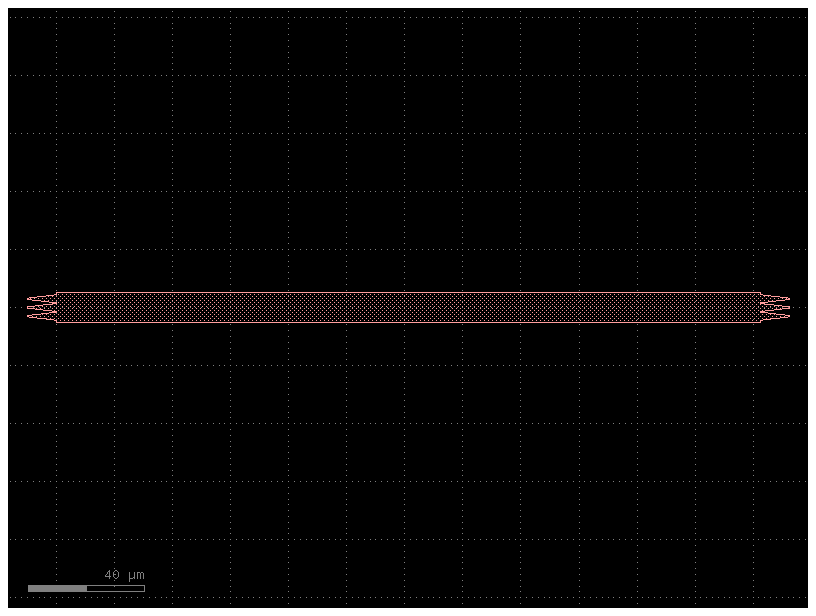

In [5]:
c = mmi3x3(width= 0.45, width_taper=2.8, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.2)

c.show()
c.plot()

## ESPIRAL: 

In [9]:
"""
Spirals for cutback prop.loss measurement
DoE: Assuming 1dB/cm loss: 1.5cm difference between spirals mean 1.5dB difference between
measurements.
"""
from upvfab.sin300.cband.cells import define_spiral_length
rad = 10
N_spr = 14
dy_spr = 10
target_length = 146050  # in microns aprox
#target_length = 146049.68378195382

dx_length_spiral = define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])
print(spiral.info["lx_final"])


Defining spiral length for delay: 146050
Spiral length set to: 4349.1796875
Spiral length 146049.852
4659.18


2026-05-11 13:49:32.904 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/3952487029.oas'
["Port(self.name='o1', self.width=450, trans=r180 *1 40,2204.59, layer=WG (1/0), port_type=optical)", "Port(self.name='o2', self.width=450, trans=r0 *1 4729.18,2204.59, layer=WG (1/0), port_type=optical)"]


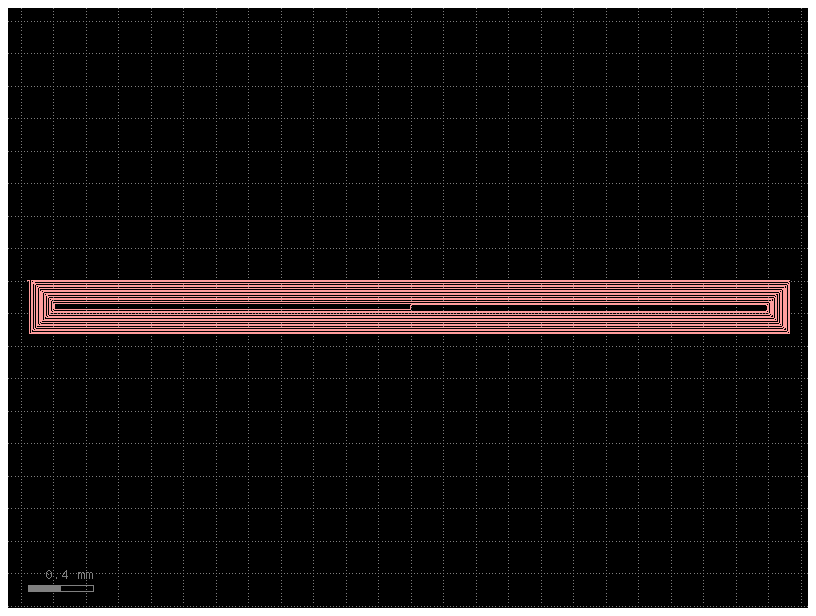

In [10]:
#DEBO CAMBIAR LA WIDTH DE LA ESPIRAL A 0.45 UM, AHORA ESTÁ EN 0.5 UM
spiral.plot()
spiral.show()
print(spiral.ports)

## CIRCUITO

2026-05-11 13:49:56.129 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/4260715479.oas'


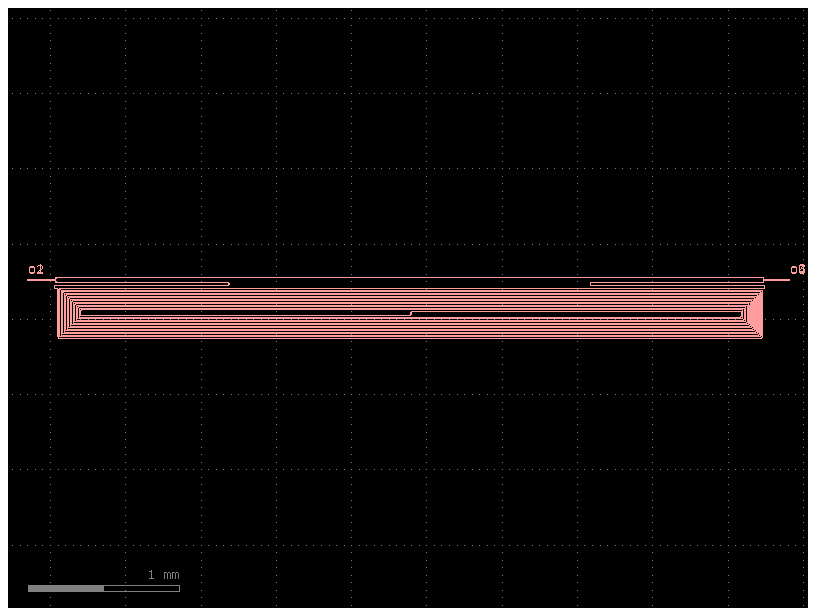

In [12]:

from functools import partial
# N espiral TIENE QUE SER PAR
def wvl_tracker(length_mmi_2x2: float = 161.433, taper_width_mmi_2x2: float = 3, gap_mmi_2x2: float = 0.4,  taper_length = 10,   length_mmi_3x3: float =  149.4331, taper_width_mmi_3x3: float = 2.6, gap_mmi_3x3: float = 0.9,  AL: float = 56000): #mejorarlo poniendo las funciones de espiral dentro
    c = gf.Component()
   
    mmi_95 = c << cells.mmi2x2(0.45, taper_width_mmi_2x2, taper_length, length_mmi_2x2, 10, gap_mmi_2x2)
    mmi_33 = c << mmi3x3(width= 0.45, width_taper=taper_width_mmi_3x3, length_taper= taper_length, length_mmi = length_mmi_3x3, width_mmi= 10, gap_mmi = gap_mmi_3x3)
    # xs_spiral = gf.cross_section.strip(width=10)
    spiral = c << cells.spiral_upv(radius = 10 , N_spr = 14 , d_SPR =10 , dx_SPR= dx_length_spiral, dy_SPR = 10) # N must BE EVEN 
    b1 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b2 = c << cells.bend_s(size = [10, 15], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    
    f_bend_euler180 = partial(cells.bend_euler,angle=180)
    h = spiral.ports["o2"].dx - spiral.ports["o1"].dx
    wvg_up = c << cells.straight(length = h, cross_section= "strip", width = 0.45)
    delay_1 = c << gf.components.delay_snake(length=h/2, length0=0, length2=0, n=2, bend180=f_bend_euler180(), cross_section='strip', width = 0.45)
    delay_2 = c << gf.components.delay_snake(length=h/2, length0=0, length2=0, n=2, bend180=f_bend_euler180(), cross_section='strip', width = 0.45)

    dy_mmi95 = mmi_95.ports["o3"].dy - mmi_95.ports["o4"].dy #para conectar los s_bend de forma que las entradas a los mmi queden a la misma altura
    dy_mmi33 = mmi_33.ports["o3"].dy - mmi_33.ports["o1"].dy
    h_bends_33 = (2*15 + dy_mmi95 - dy_mmi33)/2
    b3 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    b4 = c << cells.bend_s(size = [10, h_bends_33], cross_section = "strip", width = 0.45, allow_min_radius_violation = True)
    

    delay_1.mirror_x().mirror_y()
    delay_1.dmovex(spiral.ports["o1"].dx ).dmovey(spiral.ports["o1"].dy) 
    delay_2.mirror_y()
    delay_2.dmovex(spiral.ports["o2"].dx ).dmovey(spiral.ports["o2"].dy )
    
    b1.mirror_x()
    b1.dmovex(delay_1.ports["o2"].dx).dmovey(delay_1.ports["o2"].dy)
    mmi_95.dmovex(b1.ports["o2"].dx - length_mmi_2x2 - taper_length).dmovey(b1.ports["o2"].dy + taper_width_mmi_2x2/2  + gap_mmi_2x2/2) 
    b2.dmovex(mmi_95.ports["o3"].dx).dmovey(mmi_95.ports["o3"].dy)
    b3.dmovex(delay_2.ports["o2"].dx).dmovey(delay_2.ports["o2"].dy)
    mmi_33.dmovex(b3.ports["o2"].dx + taper_length).dmovey(b3.ports["o2"].dy + taper_width_mmi_3x3 + gap_mmi_3x3 )  
    b4.mirror_x()
    b4.dmovex(mmi_33.ports["o3"].dx).dmovey(mmi_33.ports["o3"].dy)

    wvg_up.dmovex(b2.ports["o2"].dx).dmovey(b2.ports["o2"].dy)

    c.add_port(name = "o1", port = mmi_95.ports["o2"], port_type= "optical")
    c.add_port(name = "o2", port = mmi_95.ports["o1"], port_type= "optical")
    c.add_port(name = "o3", port = mmi_33.ports["o4"], port_type= "optical")
    c.add_port(name = "o4", port = mmi_33.ports["o5"], port_type= "optical")
    c.add_port(name = "o5", port = mmi_33.ports["o6"], port_type= "optical")

    c.info["total_length_device"] = 2*taper_length + length_mmi_2x2 + 2*10 + h  + 2*taper_length + length_mmi_3x3 #2*10 es de los sbends
    c.info["length_short_arm"] = h + 2*10



    return c 

c = gf.Component()
prueba = c << wvl_tracker()
c.add_ports(prueba)
c.draw_ports()
c.plot()
c.show()


In [ ]:
prueba =  wvl_tracker()
print(f'Longitud del dispositivo: {prueba.info["total_length_device"]} um')
print(f'Longitud brazo corto: {prueba.info["length_short_arm"]} um')

4930.4241
